In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("01_data/processed/nhanes_analytic_clean.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Loaded: 5,318 rows × 29 columns

Columns: ['id', 'survey_weight', 'psu', 'strata', 'age', 'education', 'poverty_income_ratio', 'hba1c', 'systolic_bp', 'diastolic_bp', 'total_cholesterol', 'bmi', 'waist_circumference', 'self_rated_health', 'usual_care_site', 'outpatient_visits', 'er_visits', 'overnight_hosp', 'has_insurance', 'private_insurance', 'medicare', 'medicaid', 'er_visit_binary', 'hosp_binary', 'gender', 'race_ethnicity', 'told_diabetic', 'told_hypertensive', 'told_high_cholesterol']


In [2]:
## Engineer the 4 diagnosis gap flags:

# ── FLAG 1: Undiagnosed Diabetes ──
# HbA1c >= 6.5% AND not told diabetic
df["undiagnosed_diabetes"] = (
    (df["hba1c"] >= 6.5) &
    (df["told_diabetic"] == 0)
).astype(int)

# ── FLAG 2: Undiagnosed Prediabetes ──
# HbA1c 5.7–6.4% AND not told diabetic
df["undiagnosed_prediabetes"] = (
    (df["hba1c"] >= 5.7) &
    (df["hba1c"] < 6.5) &
    (df["told_diabetic"] == 0)
).astype(int)

# ── FLAG 3: Undiagnosed Hypertension ──
# Systolic >= 130 OR Diastolic >= 80 AND not told hypertensive
df["undiagnosed_hypertension"] = (
    ((df["systolic_bp"] >= 130) | (df["diastolic_bp"] >= 80)) &
    (df["told_hypertensive"] == 0)
).astype(int)

# ── FLAG 4: Undiagnosed Hyperlipidemia ──
# Total cholesterol >= 200 mg/dL AND not told high cholesterol
df["undiagnosed_hyperlipidemia"] = (
    (df["total_cholesterol"] >= 200) &
    (df["told_high_cholesterol"] == 0)
).astype(int)

# ── Verify counts ──
flags = ["undiagnosed_diabetes", "undiagnosed_prediabetes",
         "undiagnosed_hypertension", "undiagnosed_hyperlipidemia"]

print("Diagnosis Gap Flag Summary:")
print("-" * 50)
for flag in flags:
    count = df[flag].sum()
    pct   = df[flag].mean() * 100
    print(f"{flag:35s}: {count:,} ({pct:.1f}%)")

Diagnosis Gap Flag Summary:
--------------------------------------------------
undiagnosed_diabetes               : 135 (2.5%)
undiagnosed_prediabetes            : 1,265 (23.8%)
undiagnosed_hypertension           : 1,053 (19.8%)
undiagnosed_hyperlipidemia         : 907 (17.1%)


In [3]:
## Build composite risk scores and risk tiers

# ── Composite Risk Score (0-4) ──
df["composite_risk_score"] = (
    df["undiagnosed_diabetes"] +
    df["undiagnosed_prediabetes"] +
    df["undiagnosed_hypertension"] +
    df["undiagnosed_hyperlipidemia"]
)

# ── Risk Tier Categories ──
def assign_risk_tier(score):
    if score == 0:   return "No Gap"
    elif score == 1: return "Low Risk"
    elif score == 2: return "Moderate Risk"
    else:            return "High Risk"

df["risk_tier"] = df["composite_risk_score"].apply(assign_risk_tier)

# ── Risk tier order for plotting ──
tier_order = ["No Gap", "Low Risk", "Moderate Risk", "High Risk"]
df["risk_tier"] = pd.Categorical(df["risk_tier"], categories=tier_order, ordered=True)

# ── Verify distribution ──
print("Composite Risk Score Distribution:")
print(df["composite_risk_score"].value_counts().sort_index())

print("\nRisk Tier Distribution:")
tier_counts = df["risk_tier"].value_counts().reindex(tier_order)
for tier, count in tier_counts.items():
    pct = count / len(df) * 100
    print(f"  {tier:20s}: {count:,} ({pct:.1f}%)")

Composite Risk Score Distribution:
composite_risk_score
0    2692
1    1962
2     594
3      70
Name: count, dtype: int64

Risk Tier Distribution:
  No Gap              : 2,692 (50.6%)
  Low Risk            : 1,962 (36.9%)
  Moderate Risk       : 594 (11.2%)
  High Risk           : 70 (1.3%)


In [4]:
## Prevalance table by subgroups

# ── ER visit and hospitalization rate by risk tier ──
print("Utilization Rates by Risk Tier:")
print("-" * 60)
util = df.groupby("risk_tier", observed=True).agg(
    n               = ("id", "count"),
    er_visit_rate   = ("er_visit_binary", "mean"),
    hosp_rate       = ("hosp_binary", "mean")
).reset_index()

util["er_visit_rate"] = (util["er_visit_rate"] * 100).round(1)
util["hosp_rate"]     = (util["hosp_rate"] * 100).round(1)
print(util.to_string(index=False))

# ── Undiagnosed rates by race/ethnicity ──
print("\nUndiagnosed Rates by Race/Ethnicity (%):")
print("-" * 60)
race_gaps = df.groupby("race_ethnicity")[flags].mean().mul(100).round(1)
print(race_gaps.to_string())

# ── Undiagnosed rates by insurance status ──
print("\nUndiagnosed Rates by Insurance Status (%):")
print("-" * 60)
df["insurance_label"] = df["has_insurance"].map({1: "Insured", 0: "Uninsured"})
ins_gaps = df.groupby("insurance_label")[flags].mean().mul(100).round(1)
print(ins_gaps.to_string())

# ── Undiagnosed rates by income level ──
print("\nUndiagnosed Rates by Income Level (%):")
print("-" * 60)
df["income_group"] = pd.cut(
    df["poverty_income_ratio"],
    bins=[0, 1.0, 2.0, 3.5, 99],
    labels=["Below Poverty", "Low Income", "Middle Income", "Higher Income"]
)
inc_gaps = df.groupby("income_group", observed=True)[flags].mean().mul(100).round(1)
print(inc_gaps.to_string())

Utilization Rates by Risk Tier:
------------------------------------------------------------
    risk_tier    n  er_visit_rate  hosp_rate
       No Gap 2692           22.5       18.0
     Low Risk 1962           21.5       15.6
Moderate Risk  594           21.7       12.8
    High Risk   70           34.3       10.0

Undiagnosed Rates by Race/Ethnicity (%):
------------------------------------------------------------
                    undiagnosed_diabetes  undiagnosed_prediabetes  undiagnosed_hypertension  undiagnosed_hyperlipidemia
race_ethnicity                                                                                                         
Mexican American                     4.5                     27.2                      19.2                        20.2
Non-Hispanic Asian                   3.9                     24.9                      16.1                        24.9
Non-Hispanic Black                   3.6                     29.9                      17.2        

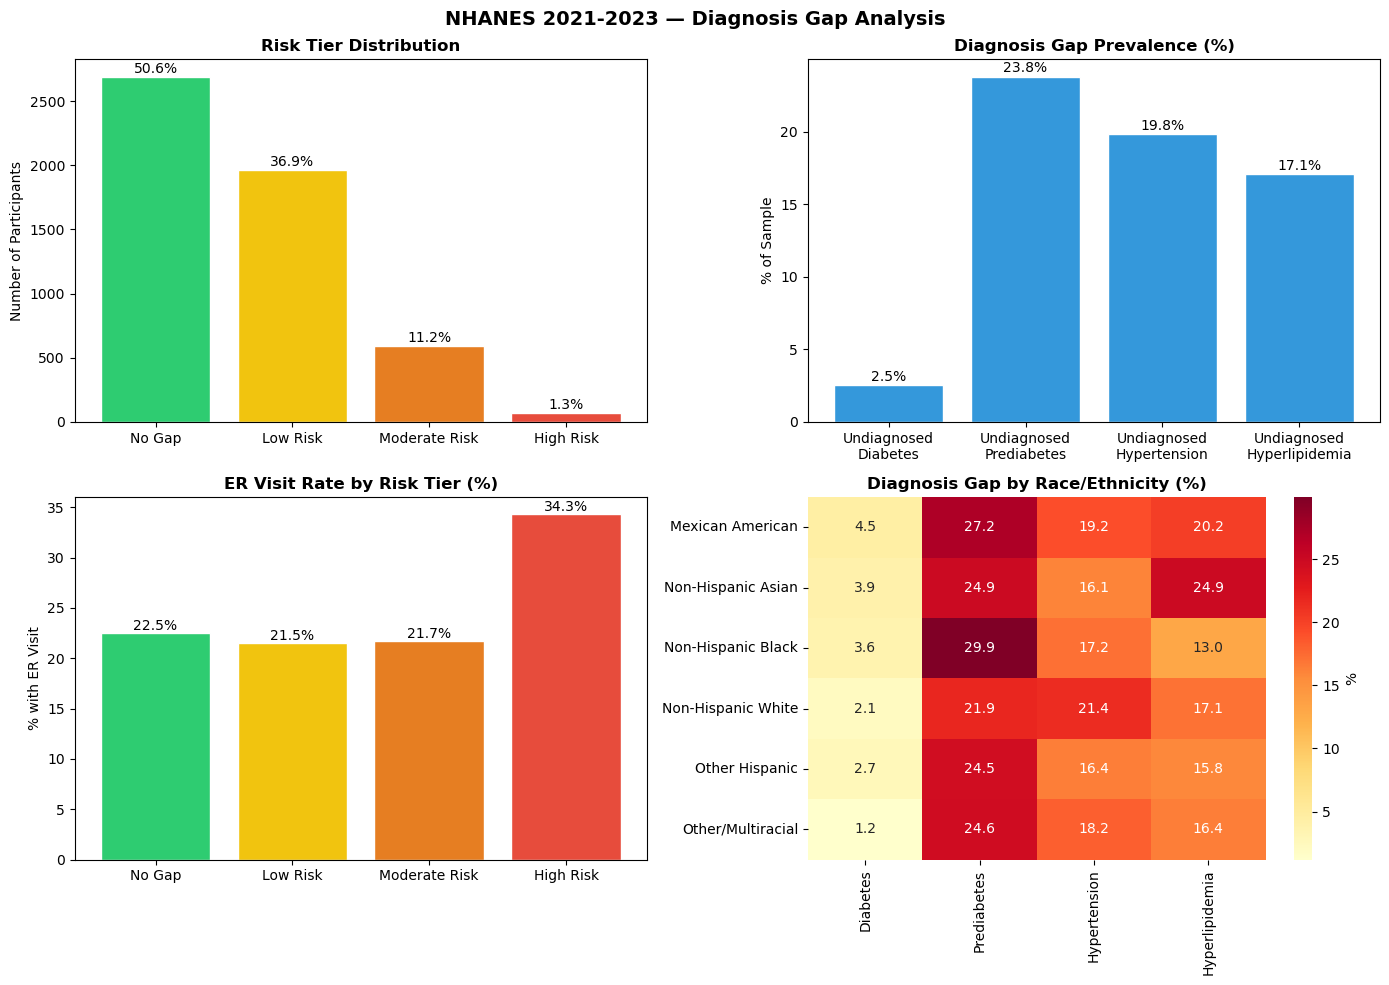

Charts saved.


In [5]:
## Exploratory Charts

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NHANES 2021-2023 — Diagnosis Gap Analysis", fontsize=14, fontweight="bold")

# ── Chart 1: Risk Tier Distribution ──
tier_pcts = df["risk_tier"].value_counts().reindex(tier_order)
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
axes[0,0].bar(tier_order, tier_pcts.values, color=colors, edgecolor="white")
axes[0,0].set_title("Risk Tier Distribution", fontweight="bold")
axes[0,0].set_ylabel("Number of Participants")
for i, v in enumerate(tier_pcts.values):
    axes[0,0].text(i, v + 30, f"{v/len(df)*100:.1f}%", ha="center", fontsize=10)

# ── Chart 2: Diagnosis Gap Prevalence ──
gap_pcts = df[flags].mean().mul(100)
gap_labels = ["Undiagnosed\nDiabetes", "Undiagnosed\nPrediabetes",
              "Undiagnosed\nHypertension", "Undiagnosed\nHyperlipidemia"]
axes[0,1].bar(gap_labels, gap_pcts.values, color="#3498db", edgecolor="white")
axes[0,1].set_title("Diagnosis Gap Prevalence (%)", fontweight="bold")
axes[0,1].set_ylabel("% of Sample")
for i, v in enumerate(gap_pcts.values):
    axes[0,1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)

# ── Chart 3: ER Visit Rate by Risk Tier ──
er_rates = df.groupby("risk_tier", observed=True)["er_visit_binary"].mean().mul(100)
axes[1,0].bar(tier_order, er_rates.reindex(tier_order).values, color=colors, edgecolor="white")
axes[1,0].set_title("ER Visit Rate by Risk Tier (%)", fontweight="bold")
axes[1,0].set_ylabel("% with ER Visit")
for i, v in enumerate(er_rates.reindex(tier_order).values):
    axes[1,0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=10)

# ── Chart 4: Diagnosis Gap by Race/Ethnicity Heatmap ──
race_heat = df.groupby("race_ethnicity")[flags].mean().mul(100).round(1)
race_heat.columns = ["Diabetes", "Prediabetes", "Hypertension", "Hyperlipidemia"]
sns.heatmap(race_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[1,1], cbar_kws={"label": "%"})
axes[1,1].set_title("Diagnosis Gap by Race/Ethnicity (%)", fontweight="bold")
axes[1,1].set_ylabel("")

plt.tight_layout()
plt.savefig("01_data/processed/phase2_diagnosis_gap_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved.")

In [6]:
output_path = "01_data/processed/nhanes_analytic_clean.csv"
df.to_csv(output_path, index=False)

print(f"✅ Updated dataset saved with engineered variables")
print(f"   Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(f"\nNew columns added:")
new_cols = flags + ["composite_risk_score", "risk_tier", 
                    "insurance_label", "income_group"]
for col in new_cols:
    print(f"  + {col}")

✅ Updated dataset saved with engineered variables
   Rows: 5,318 | Columns: 37

New columns added:
  + undiagnosed_diabetes
  + undiagnosed_prediabetes
  + undiagnosed_hypertension
  + undiagnosed_hyperlipidemia
  + composite_risk_score
  + risk_tier
  + insurance_label
  + income_group
